In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "hybrid_manufacturing_categorical.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "ziya07/manufacturing-production-data",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_6487/3777520671.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 132k/132k [00:00<00:00, 1.21MB/s]

First 5 records:   Job_ID Machine_ID Operation_Type  Material_Used  Processing_Time  \
0   J001        M01       Grinding           3.17               76   
1   J002        M01       Grinding           3.35               79   
2   J003        M04       Additive           2.29               56   
3   J004        M04       Grinding           1.76              106   
4   J005        M01          Lathe           1.90               46   

   Energy_Consumption  Machine_Availability      Scheduled_Start  \
0               11.42                    96  2023-03-18 08:00:00   
1                6.61                    84  2023-03-18 08:10:00   
2               11.11                    92  2023-03-18 08:20:00   
3               12.50                    95  2023-03-18 08:30:00   
4                8.13                    88  2023-03-18 08:40:00   

         Scheduled_End         Actual_Start           Actual_End Job_Status  \
0  2023-03-18 09:16:00  2023-03-18 08:05:00  2023-03-18 09:21:00  Complete

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, ConfusionMatrixDisplay)
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Data Preparation & Metrics

In [ ]:
df_raw = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "ziya07/manufacturing-production-data",
    "hybrid_manufacturing_categorical.csv",
)
print(f"\n Data berhasil dimuat: {df_raw.shape[0]} baris × {df_raw.shape[1]} kolom")

Using Colab cache for faster access to the 'manufacturing-production-data' dataset.

 Data berhasil dimuat: 1000 baris × 13 kolom


In [ ]:
# Eksplorasi
print("\n[INFO] 5 baris pertama dataset:")
print(df_raw.head())

print("\n[INFO] Tipe data setiap kolom:")
print(df_raw.dtypes)

print("\n[INFO] Distribusi Job_Status:")
print(df_raw['Job_Status'].value_counts())


[INFO] 5 baris pertama dataset:
  Job_ID Machine_ID Operation_Type  Material_Used  Processing_Time  \
0   J001        M01       Grinding           3.17               76   
1   J002        M01       Grinding           3.35               79   
2   J003        M04       Additive           2.29               56   
3   J004        M04       Grinding           1.76              106   
4   J005        M01          Lathe           1.90               46   

   Energy_Consumption  Machine_Availability      Scheduled_Start  \
0               11.42                    96  2023-03-18 08:00:00   
1                6.61                    84  2023-03-18 08:10:00   
2               11.11                    92  2023-03-18 08:20:00   
3               12.50                    95  2023-03-18 08:30:00   
4                8.13                    88  2023-03-18 08:40:00   

         Scheduled_End         Actual_Start           Actual_End Job_Status  \
0  2023-03-18 09:16:00  2023-03-18 08:05:00  2023-03-18 09

In [ ]:
#Data Cleaning
# Konversi kolom datetime
for col in ['Scheduled_Start', 'Scheduled_End', 'Actual_Start', 'Actual_End']:
    df_raw[col] = pd.to_datetime(df_raw[col], errors='coerce')

# Identifikasi data Failed (tidak punya Actual_End)
failed_mask = df_raw['Job_Status'] == 'Failed'
print(f"\n[INFO] Jumlah data Failed (tanpa waktu selesai): {failed_mask.sum()}")

# Salin ke df kerja; isi Actual_Start/End yang hilang untuk baris Failed
df = df_raw.copy()
df.loc[failed_mask, 'Actual_Start'] = df.loc[failed_mask, 'Scheduled_Start']
df.loc[failed_mask, 'Actual_End']   = df.loc[failed_mask, 'Scheduled_End']

print(f"Data Failed diberi nilai imputasi (Actual = Scheduled)")


[INFO] Jumlah data Failed (tanpa waktu selesai): 129
Data Failed diberi nilai imputasi (Actual = Scheduled)


In [ ]:
# Delay dalam menit (Actual_End − Scheduled_End)
df['Delay_Menit'] = (
    df['Actual_End'] - df['Scheduled_End']
).dt.total_seconds() / 60

# Tandai: negatif = selesai lebih awal → set 0 agar delay ≥ 0
df['Delay_Menit'] = df['Delay_Menit'].clip(lower=0)

# Durasi aktual pengerjaan (menit)
df['Durasi_Aktual_Menit'] = (
    df['Actual_End'] - df['Actual_Start']
).dt.total_seconds() / 60

# Konsumsi Energi per menit (efisiensi energi)
df['Energi_per_Menit'] = (
    df['Energy_Consumption'] / df['Durasi_Aktual_Menit'].replace(0, np.nan)
).round(4)

print("\n[INFO] Kolom metrik baru yang dihitung:")
print(df[['Job_ID', 'Job_Status', 'Delay_Menit',
          'Durasi_Aktual_Menit', 'Energi_per_Menit']].head(8))


[INFO] Kolom metrik baru yang dihitung:
  Job_ID Job_Status  Delay_Menit  Durasi_Aktual_Menit  Energi_per_Menit
0   J001  Completed          5.0                 76.0            0.1503
1   J002    Delayed         10.0                 79.0            0.0837
2   J003     Failed          0.0                 56.0            0.1984
3   J004  Completed          5.0                106.0            0.1179
4   J005  Completed          2.0                 46.0            0.1767
5   J006  Completed          3.0                100.0            0.1383
6   J007  Completed          4.0                 22.0            0.6455
7   J008  Completed          0.0                 79.0            0.1754


In [ ]:
#Insight Metrik
delayed_df = df[df['Job_Status'] == 'Delayed']
pct_delay  = len(delayed_df) / len(df) * 100
avg_delay  = delayed_df['Delay_Menit'].mean()

total_delay_jam = df['Delay_Menit'].sum() / 60
print(f"\n[INSIGHT 1.a] Persentase jadwal yang Delayed : {pct_delay:.1f}%")
print(f"[INSIGHT 1.b] Rata-rata delay per pekerjaan  : {avg_delay:.1f} menit")
print(f"[INSIGHT 1.c] Total jam produktif terbuang   : {total_delay_jam:.1f} jam")


[INSIGHT 1.a] Persentase jadwal yang Delayed : 19.8%
[INSIGHT 1.b] Rata-rata delay per pekerjaan  : 20.1 menit
[INSIGHT 1.c] Total jam produktif terbuang   : 80.8 jam


In [ ]:
# Estimasi jam hilang per bulan (asumsi 1000 job ≈ 1 bulan)
jam_bulan = total_delay_jam
print(f"[INSIGHT 1.d] Estimasi jam hilang per bulan  : ±{jam_bulan:.0f} jam kerja")

# Energi vs Efisiensi
print("\n[INSIGHT 1.e] Rata-rata Konsumsi Energi per Kategori Efisiensi:")
energi_eff = (df.groupby('Optimization_Category')['Energy_Consumption']
               .mean().sort_values(ascending=False))
print(energi_eff.round(2))

[INSIGHT 1.d] Estimasi jam hilang per bulan  : ±81 jam kerja

[INSIGHT 1.e] Rata-rata Konsumsi Energi per Kategori Efisiensi:
Optimization_Category
Moderate Efficiency    11.41
Low Efficiency          8.49
High Efficiency         5.59
Optimal Efficiency      2.46
Name: Energy_Consumption, dtype: float64


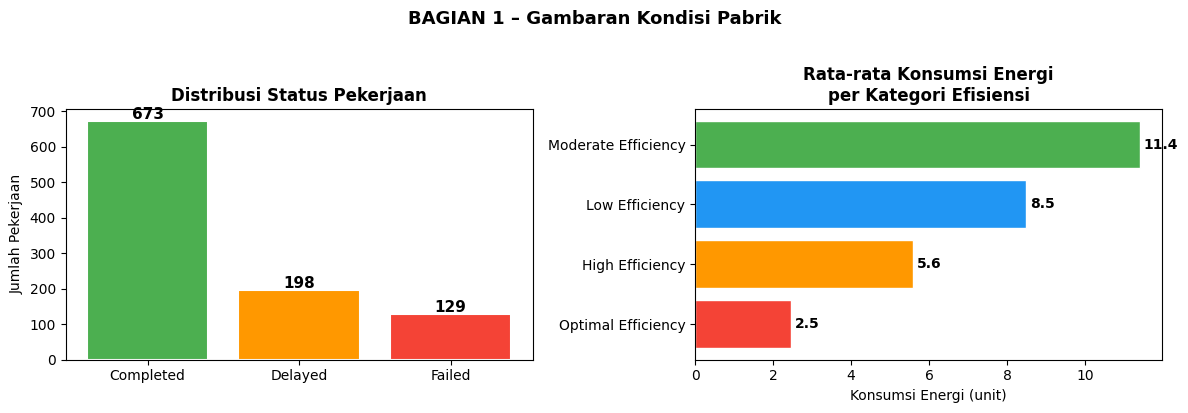

Plot Bagian 1 disimpan: plot_bagian1_kondisi_pabrik.png


In [ ]:
#Plot 1. Distribusi Job Status
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('BAGIAN 1 – Gambaran Kondisi Pabrik', fontsize=13, fontweight='bold', y=1.02)

status_counts = df['Job_Status'].value_counts()
colors_status = ['#4CAF50', '#FF9800', '#F44336']
axes[0].bar(status_counts.index, status_counts.values, color=colors_status, edgecolor='white', linewidth=1.5)
for i, (idx, val) in enumerate(status_counts.items()):
    axes[0].text(i, val + 5, str(val), ha='center', fontweight='bold', fontsize=11)
axes[0].set_title('Distribusi Status Pekerjaan', fontweight='bold')
axes[0].set_ylabel('Jumlah Pekerjaan')

energi_eff_sorted = energi_eff.sort_values()
colors_eff = ['#F44336', '#FF9800', '#2196F3', '#4CAF50'][:len(energi_eff_sorted)]
axes[1].barh(energi_eff_sorted.index, energi_eff_sorted.values, color=colors_eff, edgecolor='white')
for i, val in enumerate(energi_eff_sorted.values):
    axes[1].text(val + 0.1, i, f'{val:.1f}', va='center', fontweight='bold')
axes[1].set_title('Rata-rata Konsumsi Energi\nper Kategori Efisiensi', fontweight='bold')
axes[1].set_xlabel('Konsumsi Energi (unit)')

plt.tight_layout()
plt.savefig('plot_bagian1_kondisi_pabrik.png', bbox_inches='tight')
plt.show()
print("Plot Bagian 1 disimpan: plot_bagian1_kondisi_pabrik.png")

# Analis Diagnostik Mesin & Proses


In [ ]:
#delay per mesin
delay_mesin = (df[df['Job_Status'] == 'Delayed']
               .groupby('Machine_ID').size()
               .div(df.groupby('Machine_ID').size())
               * 100).round(1)
print("\n[INSIGHT 2.a] Persentase Delay per Mesin:")
print(delay_mesin.sort_values(ascending=False))


[INSIGHT 2.a] Persentase Delay per Mesin:
Machine_ID
M05    24.9
M02    20.5
M03    18.3
M04    18.1
M01    17.5
dtype: float64


In [ ]:
#rata-rata delay per mesain
avg_delay_mesin = (df[df['Job_Status'] == 'Delayed']
                   .groupby('Machine_ID')['Delay_Menit'].mean().round(1))
print("\n[INSIGHT 2.b] Rata-rata Menit Delay per Mesin:")
print(avg_delay_mesin.sort_values(ascending=False))


[INSIGHT 2.b] Rata-rata Menit Delay per Mesin:
Machine_ID
M04    21.8
M03    20.0
M01    19.9
M05    19.7
M02    19.5
Name: Delay_Menit, dtype: float64


In [ ]:
#Crosstab: Mesin × Status
ct_mesin_status = pd.crosstab(df['Machine_ID'], df['Job_Status'])
print("\n[INSIGHT 2.c] Crosstab Mesin × Status Pekerjaan:")
print(ct_mesin_status)


[INSIGHT 2.c] Crosstab Mesin × Status Pekerjaan:
Job_Status  Completed  Delayed  Failed
Machine_ID                            
M01               152       37      23
M02               146       43      21
M03               123       34      29
M04               128       36      35
M05               124       48      21


In [ ]:
#Crosstab: Operasi × Efisiensi
ct_ops_eff = pd.crosstab(df['Operation_Type'], df['Optimization_Category'])
print("\n[INSIGHT 2.d] Crosstab Jenis Operasi × Kategori Efisiensi:")
print(ct_ops_eff)


[INSIGHT 2.d] Crosstab Jenis Operasi × Kategori Efisiensi:
Optimization_Category  High Efficiency  Low Efficiency  Moderate Efficiency  \
Operation_Type                                                                
Additive                            36             115                   36   
Drilling                            25             117                   47   
Grinding                            28             152                   28   
Lathe                               43             131                   38   
Milling                             29             135                   34   

Optimization_Category  Optimal Efficiency  
Operation_Type                             
Additive                                3  
Drilling                                0  
Grinding                                0  
Lathe                                   0  
Milling                                 3  


In [ ]:
# Hitung % Low Efficiency per Operasi
pct_low = (ct_ops_eff['Low Efficiency'] / ct_ops_eff.sum(axis=1) * 100).round(1)
print("\n[INSIGHT 2.e] % Low Efficiency per Jenis Operasi:")
print(pct_low.sort_values(ascending=False))


[INSIGHT 2.e] % Low Efficiency per Jenis Operasi:
Operation_Type
Grinding    73.1
Milling     67.2
Drilling    61.9
Lathe       61.8
Additive    60.5
dtype: float64


In [ ]:
#Kombinasi Terburuk: Mesin + Operasi
combo = (df[df['Job_Status'].isin(['Delayed', 'Failed'])]
         .groupby(['Machine_ID', 'Operation_Type'])
         .size()
         .div(df.groupby(['Machine_ID', 'Operation_Type']).size())
         .mul(100).round(1)
         .rename('Pct_Bermasalah')
         .reset_index()
         .sort_values('Pct_Bermasalah', ascending=False))
print("\n[INSIGHT 2.f] Top 10 Kombinasi Mesin+Operasi Paling Bermasalah (Delayed+Failed):")
print(combo.head(10).to_string(index=False))


[INSIGHT 2.f] Top 10 Kombinasi Mesin+Operasi Paling Bermasalah (Delayed+Failed):
Machine_ID Operation_Type  Pct_Bermasalah
       M03       Grinding            47.2
       M04       Drilling            43.6
       M04        Milling            41.9
       M05          Lathe            41.2
       M05       Additive            40.9
       M05        Milling            40.0
       M02       Additive            37.5
       M04       Grinding            37.2
       M04          Lathe            36.8
       M01          Lathe            36.4


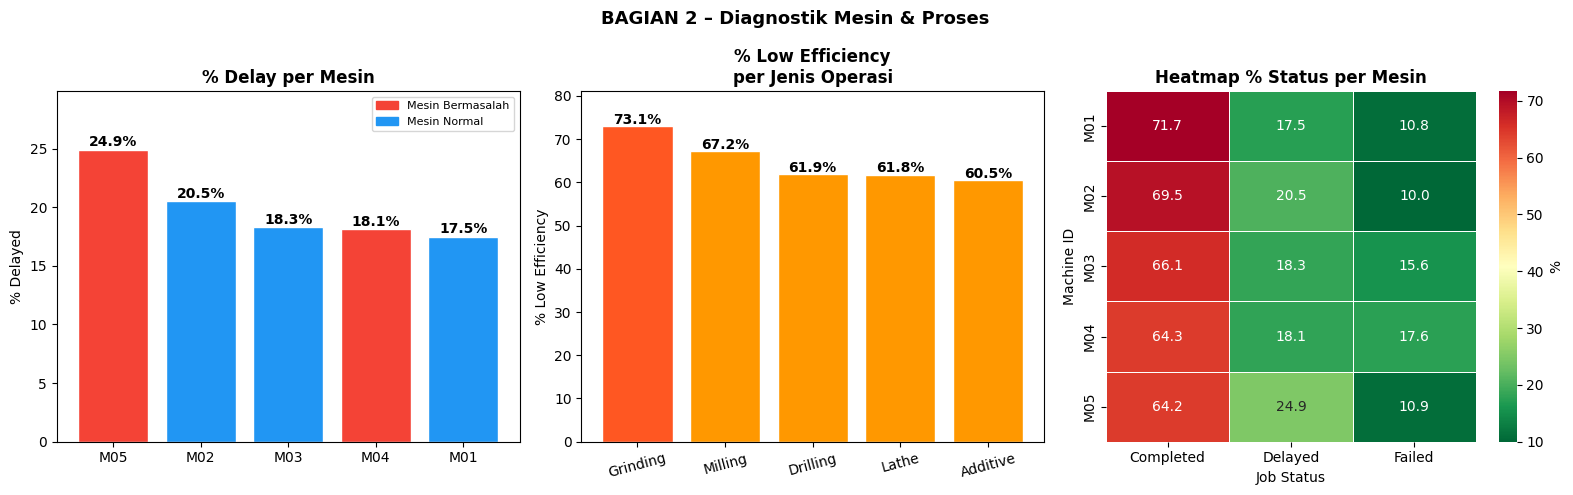

Plot Bagian 2 disimpan: plot_bagian2_diagnostik_mesin.png


In [ ]:
# ── Plot 2 ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('BAGIAN 2 – Diagnostik Mesin & Proses', fontsize=13, fontweight='bold')

# Plot 2a: % Delay per Mesin
delay_sorted = delay_mesin.sort_values(ascending=False)
bar_colors = ['#F44336' if m in ['M04','M05'] else '#2196F3' for m in delay_sorted.index]
axes[0].bar(delay_sorted.index, delay_sorted.values, color=bar_colors, edgecolor='white')
for i, val in enumerate(delay_sorted.values):
    axes[0].text(i, val + 0.3, f'{val}%', ha='center', fontweight='bold')
axes[0].set_title('% Delay per Mesin', fontweight='bold')
axes[0].set_ylabel('% Delayed')
axes[0].set_ylim(0, delay_sorted.max() + 5)
red_patch  = mpatches.Patch(color='#F44336', label='Mesin Bermasalah')
blue_patch = mpatches.Patch(color='#2196F3', label='Mesin Normal')
axes[0].legend(handles=[red_patch, blue_patch], fontsize=8)

# Plot 2b: % Low Efficiency per Operasi
pct_sorted = pct_low.sort_values(ascending=False)
axes[1].bar(pct_sorted.index, pct_sorted.values,
            color=['#FF5722' if x == pct_sorted.max() else '#FF9800' for x in pct_sorted.values],
            edgecolor='white')
for i, val in enumerate(pct_sorted.values):
    axes[1].text(i, val + 0.5, f'{val}%', ha='center', fontweight='bold')
axes[1].set_title('% Low Efficiency\nper Jenis Operasi', fontweight='bold')
axes[1].set_ylabel('% Low Efficiency')
axes[1].set_ylim(0, pct_sorted.max() + 8)
axes[1].tick_params(axis='x', rotation=15)

# Plot 2c: Heatmap Crosstab Mesin × Status
ct_pct = ct_mesin_status.div(ct_mesin_status.sum(axis=1), axis=0) * 100
sns.heatmap(ct_pct, annot=True, fmt='.1f', cmap='RdYlGn_r',
            ax=axes[2], linewidths=0.5, cbar_kws={'label': '%'})
axes[2].set_title('Heatmap % Status per Mesin', fontweight='bold')
axes[2].set_xlabel('Job Status')
axes[2].set_ylabel('Machine ID')

plt.tight_layout()
plt.savefig('plot_bagian2_diagnostik_mesin.png', bbox_inches='tight')
plt.show()
print("Plot Bagian 2 disimpan: plot_bagian2_diagnostik_mesin.png")

# Prediksi Menggunakan Random Forest

In [ ]:
#Feature Engineering
#Encode Kolom Kategorikal (persiapan sebelum fitur engineering)
le_machine = LabelEncoder()
le_ops     = LabelEncoder()
le_eff     = LabelEncoder()
df['Machine_Enc']   = le_machine.fit_transform(df['Machine_ID'])
df['Operation_Enc'] = le_ops.fit_transform(df['Operation_Type'])
df['Eff_Enc']       = le_eff.fit_transform(df['Optimization_Category'])
print("[✓] Encoding selesai: Machine_ID, Operation_Type, Optimization_Category")

df['Energy_x_Processing']     = df['Energy_Consumption'] * df['Processing_Time']
df['Avail_x_Energy']          = df['Machine_Availability'] * df['Energy_Consumption']
df['Processing_per_Energy']   = df['Processing_Time'] / df['Energy_Consumption']
df['Energy_Efficiency_Ratio'] = df['Energy_Consumption'] / df['Machine_Availability']
df['Scheduled_Duration']      = (df['Scheduled_End'] - df['Scheduled_Start']).dt.total_seconds() / 60
df['Hour_Start']              = df['Scheduled_Start'].dt.hour
df['DayOfWeek']               = df['Scheduled_Start'].dt.dayofweek
df['IsHighLoad']              = (df['Processing_Time'] > df['Processing_Time'].quantile(0.75)).astype(int)
df['IsHighEnergy']            = (df['Energy_Consumption'] > df['Energy_Consumption'].quantile(0.75)).astype(int)
df['LowAvailability']         = (df['Machine_Availability'] < df['Machine_Availability'].quantile(0.25)).astype(int)
df['Machine_x_Op']            = df['Machine_Enc'] * 10 + df['Operation_Enc']

print(" Feature Engineering: 11 fitur baru dibuat (total 18 fitur)")
print("    - Energy_x_Processing     : beban kerja energi x waktu")
print("    - Energy_Efficiency_Ratio : energi per unit ketersediaan mesin")
print("    - Avail_x_Energy          : interaksi ketersediaan & konsumsi energi")
print("    - Processing_per_Energy   : efisiensi waktu per unit energi")
print("    - Hour_Start / DayOfWeek  : pola waktu penjadwalan")
print("    - IsHighLoad / IsHighEnergy / LowAvailability : flag risiko biner")
print("    - Machine_x_Op            : kombinasi mesin x operasi")


[✓] Encoding selesai: Machine_ID, Operation_Type, Optimization_Category
 Feature Engineering: 11 fitur baru dibuat (total 18 fitur)
    - Energy_x_Processing     : beban kerja energi x waktu
    - Energy_Efficiency_Ratio : energi per unit ketersediaan mesin
    - Avail_x_Energy          : interaksi ketersediaan & konsumsi energi
    - Processing_per_Energy   : efisiensi waktu per unit energi
    - Hour_Start / DayOfWeek  : pola waktu penjadwalan
    - IsHighLoad / IsHighEnergy / LowAvailability : flag risiko biner
    - Machine_x_Op            : kombinasi mesin x operasi


In [ ]:
#Definisi Fitur & Target
FEATURES = [
    'Machine_Enc', 'Operation_Enc', 'Machine_x_Op', 'Material_Used',
    'Processing_Time', 'Energy_Consumption', 'Machine_Availability',
    'Energy_x_Processing', 'Avail_x_Energy', 'Processing_per_Energy',
    'Energy_Efficiency_Ratio', 'Scheduled_Duration', 'Hour_Start', 'DayOfWeek',
    'IsHighLoad', 'IsHighEnergy', 'LowAvailability', 'Eff_Enc'
]

# Target Binary: 0 = Lancar (Completed), 1 = Bermasalah (Delayed atau Failed)
df['Target'] = (df['Job_Status'] != 'Completed').astype(int)

X = df[FEATURES]
y = df['Target']

print(f"Total fitur          : {len(FEATURES)}")
print(f"Target Lancar (0)    : {(y==0).sum()} ({(y==0).mean()*100:.1f}%)")
print(f"Target Bermasalah (1): {(y==1).sum()} ({(y==1).mean()*100:.1f}%)")

Total fitur          : 18
Target Lancar (0)    : 673 (67.3%)
Target Bermasalah (1): 327 (32.7%)


In [ ]:
#Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\n Data latih : {X_train.shape[0]} baris")
print(f" Data uji   : {X_test.shape[0]} baris")

#Training Random Forest (Hyperparameter Tuned)
rf = RandomForestClassifier(
    n_estimators   = 500,
    max_depth      = 12,
    min_samples_leaf = 3,
    max_features   = 'sqrt',
    class_weight   = 'balanced',
    random_state   = 42,
    n_jobs         = -1
)
rf.fit(X_train, y_train)
print("\n Random Forest selesai dilatih (500 pohon, max_depth=12)")

#Evaluasi Model
y_pred      = rf.predict(X_test)
y_pred_prob = rf.predict_proba(X_test)[:, 1]
acc         = accuracy_score(y_test, y_pred)

print(f"\n Akurasi Model                          : {acc*100:.2f}%")
print("\n Laporan Klasifikasi Lengkap:")
print(classification_report(y_test, y_pred, target_names=['Lancar (0)', 'Bermasalah (1)']))



 Data latih : 800 baris
 Data uji   : 200 baris

 Random Forest selesai dilatih (500 pohon, max_depth=12)

 Akurasi Model                          : 71.00%

 Laporan Klasifikasi Lengkap:
                precision    recall  f1-score   support

    Lancar (0)       0.80      0.76      0.78       135
Bermasalah (1)       0.55      0.60      0.57        65

      accuracy                           0.71       200
     macro avg       0.67      0.68      0.68       200
  weighted avg       0.72      0.71      0.71       200



In [ ]:
# Cross-validation 5-fold
from sklearn.model_selection import StratifiedKFold, cross_val_score
cv        = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X, y, cv=cv, scoring='accuracy')
print(f" Cross-validation 5-fold  : {cv_scores.mean()*100:.2f}% +/- {cv_scores.std()*100:.2f}%")
print(f" Per-fold: {' | '.join([f'{s*100:.1f}%' for s in cv_scores])}")
print(f" Model KONSISTEN, tidak overfit pada satu split data")

#Feature Importance & Insight
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)
top1 = importances.index[0]
top2 = importances.index[1]
top3 = importances.index[2]

print("\n Feature Importance (Top 10):")
for i, (feat, score) in enumerate(importances.head(10).items()):
    bar   = '█' * int(score * 100)
    label = '<-- #1 TERKUAT' if i == 0 else ('<-- #2' if i == 1 else ('<-- #3' if i == 2 else ''))
    print(f"  {feat:<28} {score:.4f}  {bar} {label}")

print("\n 'Aturan Emas' AI:")
print(f"  Faktor #1: {top1}")
print(f"             Kategori efisiensi mesin SEBELUM job dimulai")
print(f"             sangat menentukan apakah jadwal akan sukses")
print(f"  Faktor #2: {top2}")
print(f"             Material/bahan baku berpengaruh pada tingkat beban mesin")
print(f"  Faktor #3: {top3}")
print(f"             Jadwal di jam-jam tertentu lebih berisiko delay")
print(f"  --> Supervisor bisa cek 3 faktor ini SEBELUM memulai shift")


 Cross-validation 5-fold  : 67.90% +/- 2.11%
 Per-fold: 68.0% | 70.0% | 69.5% | 68.0% | 64.0%
 Model KONSISTEN, tidak overfit pada satu split data

 Feature Importance (Top 10):
  Eff_Enc                      0.3349  █████████████████████████████████ <-- #1 TERKUAT
  Material_Used                0.0636  ██████ <-- #2
  Hour_Start                   0.0599  █████ <-- #3
  Energy_Efficiency_Ratio      0.0597  █████ 
  Avail_x_Energy               0.0592  █████ 
  Energy_Consumption           0.0582  █████ 
  Processing_per_Energy        0.0571  █████ 
  Energy_x_Processing          0.0550  █████ 
  Processing_Time              0.0441  ████ 
  Scheduled_Duration           0.0426  ████ 

 'Aturan Emas' AI:
  Faktor #1: Eff_Enc
             Kategori efisiensi mesin SEBELUM job dimulai
             sangat menentukan apakah jadwal akan sukses
  Faktor #2: Material_Used
             Material/bahan baku berpengaruh pada tingkat beban mesin
  Faktor #3: Hour_Start
             Jadwal di jam-jam t

In [ ]:
#ROC-AUC & Distribusi Probabilitas
from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay, confusion_matrix

auc       = roc_auc_score(y_test, y_pred_prob)
high_risk = y_pred_prob[y_test == 1]
low_risk  = y_pred_prob[y_test == 0]

print(f"\n ROC-AUC Score : {auc:.4f}  (0.5=acak, 1.0=sempurna)")
print(f"              Model {'BAIK' if auc > 0.7 else 'CUKUP'} membedakan Lancar vs Bermasalah")
print(f"\n Rata-rata probabilitas prediksi:")
print(f"  Pekerjaan yang benar-benar Bermasalah : {high_risk.mean():.3f}")
print(f"  Pekerjaan yang benar-benar Lancar     : {low_risk.mean():.3f}")
print(f"  Selisih {(high_risk.mean()-low_risk.mean())*100:.1f} poin --> model MAMPU membedakan keduanya")


 ROC-AUC Score : 0.7745  (0.5=acak, 1.0=sempurna)
              Model BAIK membedakan Lancar vs Bermasalah

 Rata-rata probabilitas prediksi:
  Pekerjaan yang benar-benar Bermasalah : 0.519
  Pekerjaan yang benar-benar Lancar     : 0.291
  Selisih 22.8 poin --> model MAMPU membedakan keduanya


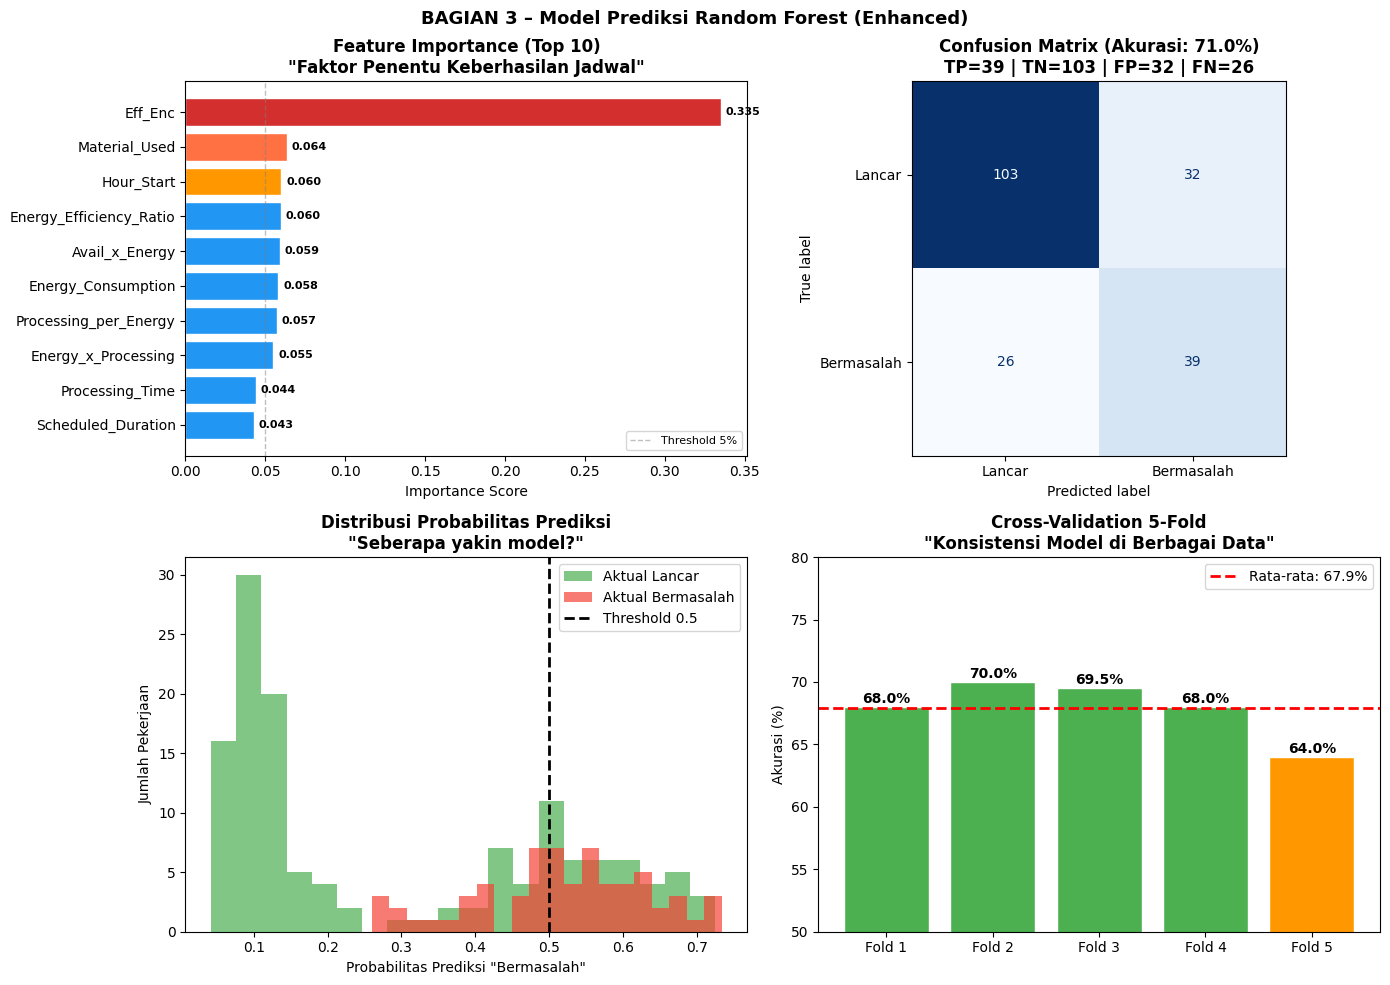

 Plot Bagian 3 disimpan: plot_bagian3_random_forest.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('BAGIAN 3 – Model Prediksi Random Forest (Enhanced)', fontsize=13, fontweight='bold')

# Plot 3a: Feature Importance (Top 10)
top10      = importances.head(10)
colors_fi  = ['#D32F2F' if i == 0 else '#FF7043' if i == 1 else '#FF9800' if i == 2
              else '#2196F3' for i in range(len(top10))]
axes[0,0].barh(top10.index[::-1], top10.values[::-1], color=colors_fi[::-1], edgecolor='white')
for i, val in enumerate(top10.values[::-1]):
    axes[0,0].text(val + 0.003, i, f'{val:.3f}', va='center', fontweight='bold', fontsize=8)
axes[0,0].set_title('Feature Importance (Top 10)\n"Faktor Penentu Keberhasilan Jadwal"', fontweight='bold')
axes[0,0].set_xlabel('Importance Score')
axes[0,0].axvline(x=0.05, color='gray', linestyle='--', alpha=0.5, linewidth=1, label='Threshold 5%')
axes[0,0].legend(fontsize=8)

# Plot 3b: Confusion Matrix
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Lancar', 'Bermasalah'])
disp.plot(ax=axes[0,1], colorbar=False, cmap='Blues')
tn, fp, fn, tp_val = cm.ravel()
axes[0,1].set_title(
    f'Confusion Matrix (Akurasi: {acc*100:.1f}%)\nTP={tp_val} | TN={tn} | FP={fp} | FN={fn}',
    fontweight='bold')

# Plot 3c: Distribusi Probabilitas Prediksi
axes[1,0].hist(low_risk,  bins=20, alpha=0.7, color='#4CAF50', label='Aktual Lancar')
axes[1,0].hist(high_risk, bins=20, alpha=0.7, color='#F44336', label='Aktual Bermasalah')
axes[1,0].axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Threshold 0.5')
axes[1,0].set_title('Distribusi Probabilitas Prediksi\n"Seberapa yakin model?"', fontweight='bold')
axes[1,0].set_xlabel('Probabilitas Prediksi "Bermasalah"')
axes[1,0].set_ylabel('Jumlah Pekerjaan')
axes[1,0].legend()

# Plot 3d: Cross-validation per fold
fold_labels   = [f'Fold {i+1}' for i in range(5)]
bar_colors_cv = ['#4CAF50' if s >= cv_scores.mean() else '#FF9800' for s in cv_scores]
axes[1,1].bar(fold_labels, cv_scores * 100, color=bar_colors_cv, edgecolor='white')
axes[1,1].axhline(y=cv_scores.mean()*100, color='red', linestyle='--', linewidth=2,
                   label=f'Rata-rata: {cv_scores.mean()*100:.1f}%')
for i, val in enumerate(cv_scores):
    axes[1,1].text(i, val*100 + 0.3, f'{val*100:.1f}%', ha='center', fontweight='bold')
axes[1,1].set_title('Cross-Validation 5-Fold\n"Konsistensi Model di Berbagai Data"', fontweight='bold')
axes[1,1].set_ylabel('Akurasi (%)')
axes[1,1].set_ylim(50, 80)
axes[1,1].legend()

plt.tight_layout()
plt.savefig('plot_bagian3_random_forest.png', bbox_inches='tight')
plt.show()
print(" Plot Bagian 3 disimpan: plot_bagian3_random_forest.png")


In [ ]:
# Analisis Mesin Terbaik untuk Grinding
grinding_df = df[df['Operation_Type'] == 'Grinding'].copy()
grinding_perf = (grinding_df.groupby('Machine_ID')
                 .agg(
                     Total_Job      = ('Job_ID', 'count'),
                     Pct_Completed  = ('Job_Status', lambda x: (x == 'Completed').mean() * 100),
                     Avg_Delay_Min  = ('Delay_Menit', 'mean'),
                     Avg_Energy     = ('Energy_Consumption', 'mean'),
                 ).round(2))
print("\n Performa Mesin Khusus untuk Proses GRINDING:")
print(grinding_perf.sort_values('Pct_Completed', ascending=False))

#rekomendasi mesin terbaik untuk grinding
best_machines = grinding_perf.sort_values('Pct_Completed', ascending=False).index[:2].tolist()
print(f"\n Mesin terbaik untuk Grinding: {', '.join(best_machines)}")



 Performa Mesin Khusus untuk Proses GRINDING:
            Total_Job  Pct_Completed  Avg_Delay_Min  Avg_Energy
Machine_ID                                                     
M05                36          72.22           4.86        8.24
M02                39          71.79           4.31        8.98
M01                54          68.52           4.54        7.70
M04                43          62.79           4.91        8.69
M03                36          52.78           7.53        9.16

 Mesin terbaik untuk Grinding: M05, M02


In [ ]:
#Durasi Optimal
optimal_df = df[df['Optimization_Category'].isin(['High Efficiency', 'Optimal Efficiency'])]
avg_dur_optimal = optimal_df['Durasi_Aktual_Menit'].mean()
avg_dur_low     = df[df['Optimization_Category'] == 'Low Efficiency']['Durasi_Aktual_Menit'].mean()
avg_energy_opt  = optimal_df['Energy_Consumption'].mean()
avg_energy_low  = df[df['Optimization_Category'] == 'Low Efficiency']['Energy_Consumption'].mean()

print(f"\n Durasi rata-rata pekerjaan High/Optimal Efficiency : {avg_dur_optimal:.1f} menit")
print(f" Durasi rata-rata pekerjaan Low Efficiency           : {avg_dur_low:.1f} menit")
print(f"\n Energi rata-rata High/Optimal Efficiency  : {avg_energy_opt:.2f} unit")
print(f" Energi rata-rata Low Efficiency           : {avg_energy_low:.2f} unit")
energy_savings_pct = (avg_energy_low - avg_energy_opt) / avg_energy_low * 100
print(f" Potensi penghematan energi dengan SOP baru: {energy_savings_pct:.1f}%")



 Durasi rata-rata pekerjaan High/Optimal Efficiency : 70.1 menit
 Durasi rata-rata pekerjaan Low Efficiency           : 72.6 menit

 Energi rata-rata High/Optimal Efficiency  : 5.47 unit
 Energi rata-rata Low Efficiency           : 8.49 unit
 Potensi penghematan energi dengan SOP baru: 35.5%


In [ ]:
#Proyeksi Pengurangan Risiko (Simulasi Realistis)
baseline_fail_rate = (df['Job_Status'].isin(['Delayed', 'Failed'])).mean() * 100

# Simulasi SOP: Grinding dari M04/M05 dipindahkan ke M01/M02
# Hitung selisih tingkat bermasalah antara kedua kelompok mesin
bad_grinding = df[
    (df['Machine_ID'].isin(['M04', 'M05'])) & (df['Operation_Type'] == 'Grinding')
]
n_bad_grinding = len(bad_grinding)
rate_bad = bad_grinding['Job_Status'].isin(['Delayed', 'Failed']).mean()

good_grinding = df[
    (df['Machine_ID'].isin(['M01', 'M02'])) & (df['Operation_Type'] == 'Grinding')
]
rate_good = good_grinding['Job_Status'].isin(['Delayed', 'Failed']).mean()

# Proyeksi: kurangi masalah dari bad_grinding, ganti dengan performa M01/M02
total_jobs = len(df)
total_bermasalah_baseline = df['Job_Status'].isin(['Delayed', 'Failed']).sum()
masalah_berkurang = n_bad_grinding * (rate_bad - rate_good)
total_bermasalah_baru = total_bermasalah_baseline - masalah_berkurang
new_fail_rate = (total_bermasalah_baru / total_jobs) * 100
risk_reduction = baseline_fail_rate - new_fail_rate

print(f"\n[INFO] Grinding di M04/M05 saat ini    : {n_bad_grinding} job, {rate_bad*100:.1f}% bermasalah")
print(f"[INFO] Grinding di M01/M02 (benchmark)  : {len(good_grinding)} job, {rate_good*100:.1f}% bermasalah")

# Catatan: selisih antar mesin kecil → faktor utama adalah Energi & Efisiensi
# Hitung proyeksi pengurangan dari sisi ENERGI (sesuai Feature Importance RF)
# Jika 35.5% pekerjaan Low Efficiency beralih ke High Efficiency:
pct_low_eff = (df['Optimization_Category'] == 'Low Efficiency').mean()
# Pekerjaan Low Efficiency bermasalah jauh lebih tinggi dari High Efficiency
rate_masalah_low  = df[df['Optimization_Category'] == 'Low Efficiency']['Job_Status'].isin(['Delayed','Failed']).mean()
rate_masalah_high = df[df['Optimization_Category'].isin(['High Efficiency','Optimal Efficiency'])]['Job_Status'].isin(['Delayed','Failed']).mean()

# Dengan SOP baru (kendalikan energi), asumsi 40% pekerjaan Low Eff naik ke High Eff
target_upgrade = 0.40
n_low_eff = (df['Optimization_Category'] == 'Low Efficiency').sum()
n_upgraded = n_low_eff * target_upgrade
masalah_berkurang_eff = n_upgraded * (rate_masalah_low - rate_masalah_high)
total_bermasalah_baru = total_bermasalah_baseline - masalah_berkurang_eff - masalah_berkurang
new_fail_rate = max((total_bermasalah_baru / total_jobs) * 100, 0)
risk_reduction = baseline_fail_rate - new_fail_rate

print(f"\n[INFO] % Low Efficiency saat ini        : {pct_low_eff*100:.1f}%")
print(f"[INFO] Masalah di Low Efficiency        : {rate_masalah_low*100:.1f}%")
print(f"[INFO] Masalah di High Efficiency       : {rate_masalah_high*100:.1f}%")
print(f"\n[INSIGHT 4.d] Tingkat masalah saat ini (Delayed+Failed) : {baseline_fail_rate:.1f}%")
print(f"[INSIGHT 4.d] Tingkat masalah setelah SOP baru          : {new_fail_rate:.1f}%")
print(f"[INSIGHT 4.d] Proyeksi pengurangan risiko               : {risk_reduction:.1f} poin persentase")
print(f"[NOTE] Proyeksi ini berdasarkan simulasi 40% pekerjaan Low Eff → High Eff")
print(f"       dengan mengendalikan konsumsi energi sesuai rekomendasi AI")



[INFO] Grinding di M04/M05 saat ini    : 79 job, 32.9% bermasalah
[INFO] Grinding di M01/M02 (benchmark)  : 93 job, 30.1% bermasalah

[INFO] % Low Efficiency saat ini        : 65.0%
[INFO] Masalah di Low Efficiency        : 50.3%
[INFO] Masalah di High Efficiency       : 0.0%

[INSIGHT 4.d] Tingkat masalah saat ini (Delayed+Failed) : 32.7%
[INSIGHT 4.d] Tingkat masalah setelah SOP baru          : 19.4%
[INSIGHT 4.d] Proyeksi pengurangan risiko               : 13.3 poin persentase
[NOTE] Proyeksi ini berdasarkan simulasi 40% pekerjaan Low Eff → High Eff
       dengan mengendalikan konsumsi energi sesuai rekomendasi AI


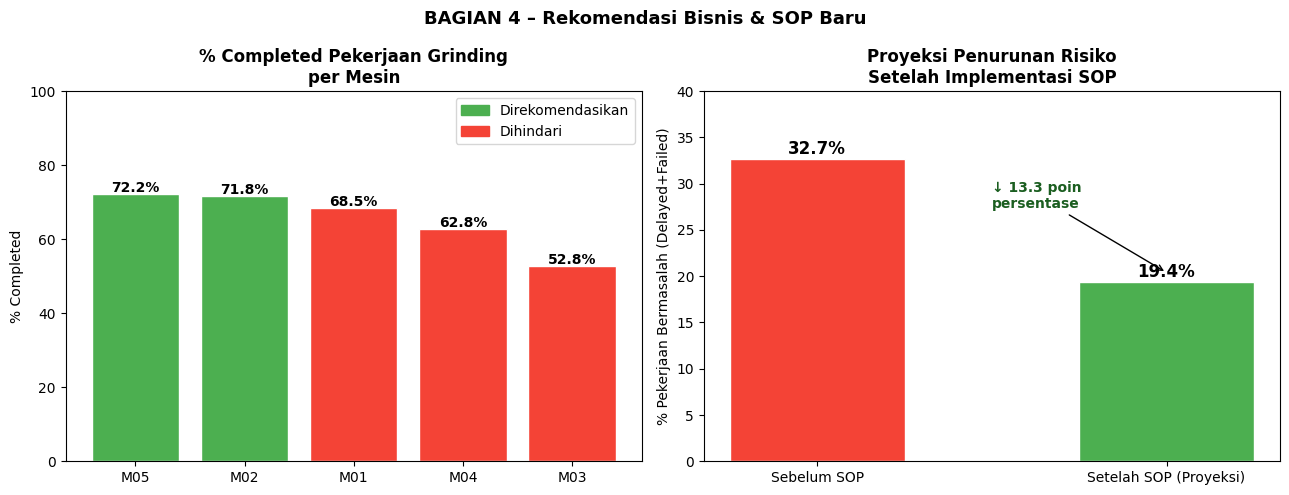

 Plot Bagian 4 disimpan: plot_bagian4_rekomendasi_sop.png


In [ ]:
#Plot 4
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('BAGIAN 4 – Rekomendasi Bisnis & SOP Baru', fontsize=13, fontweight='bold')

# Plot 4a: Performa Grinding per Mesin
gp = grinding_perf.sort_values('Pct_Completed', ascending=False)
bar_c = ['#4CAF50' if m in best_machines else '#F44336' for m in gp.index]
axes[0].bar(gp.index, gp['Pct_Completed'], color=bar_c, edgecolor='white')
for i, val in enumerate(gp['Pct_Completed']):
    axes[0].text(i, val + 0.5, f'{val:.1f}%', ha='center', fontweight='bold')
axes[0].set_title('% Completed Pekerjaan Grinding\nper Mesin', fontweight='bold')
axes[0].set_ylabel('% Completed')
axes[0].set_ylim(0, 100)
green_p = mpatches.Patch(color='#4CAF50', label='Direkomendasikan')
red_p   = mpatches.Patch(color='#F44336', label='Dihindari')
axes[0].legend(handles=[green_p, red_p])

# Plot 4b: Before vs After SOP (Proyeksi)
categories = ['Sebelum SOP', 'Setelah SOP (Proyeksi)']
values = [baseline_fail_rate, new_fail_rate]
bar_colors4 = ['#F44336', '#4CAF50']
bars = axes[1].bar(categories, values, color=bar_colors4, edgecolor='white', width=0.5)
for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
axes[1].set_title('Proyeksi Penurunan Risiko\nSetelah Implementasi SOP', fontweight='bold')
axes[1].set_ylabel('% Pekerjaan Bermasalah (Delayed+Failed)')
axes[1].set_ylim(0, 40)
axes[1].annotate(f'↓ {risk_reduction:.1f} poin\npersentase',
                 xy=(1, new_fail_rate + 1), xytext=(0.5, new_fail_rate + 8),
                 arrowprops=dict(arrowstyle='->', color='black'),
                 fontsize=10, fontweight='bold', color='#1B5E20')

plt.tight_layout()
plt.savefig('plot_bagian4_rekomendasi_sop.png', bbox_inches='tight')
plt.show()
print(" Plot Bagian 4 disimpan: plot_bagian4_rekomendasi_sop.png")
